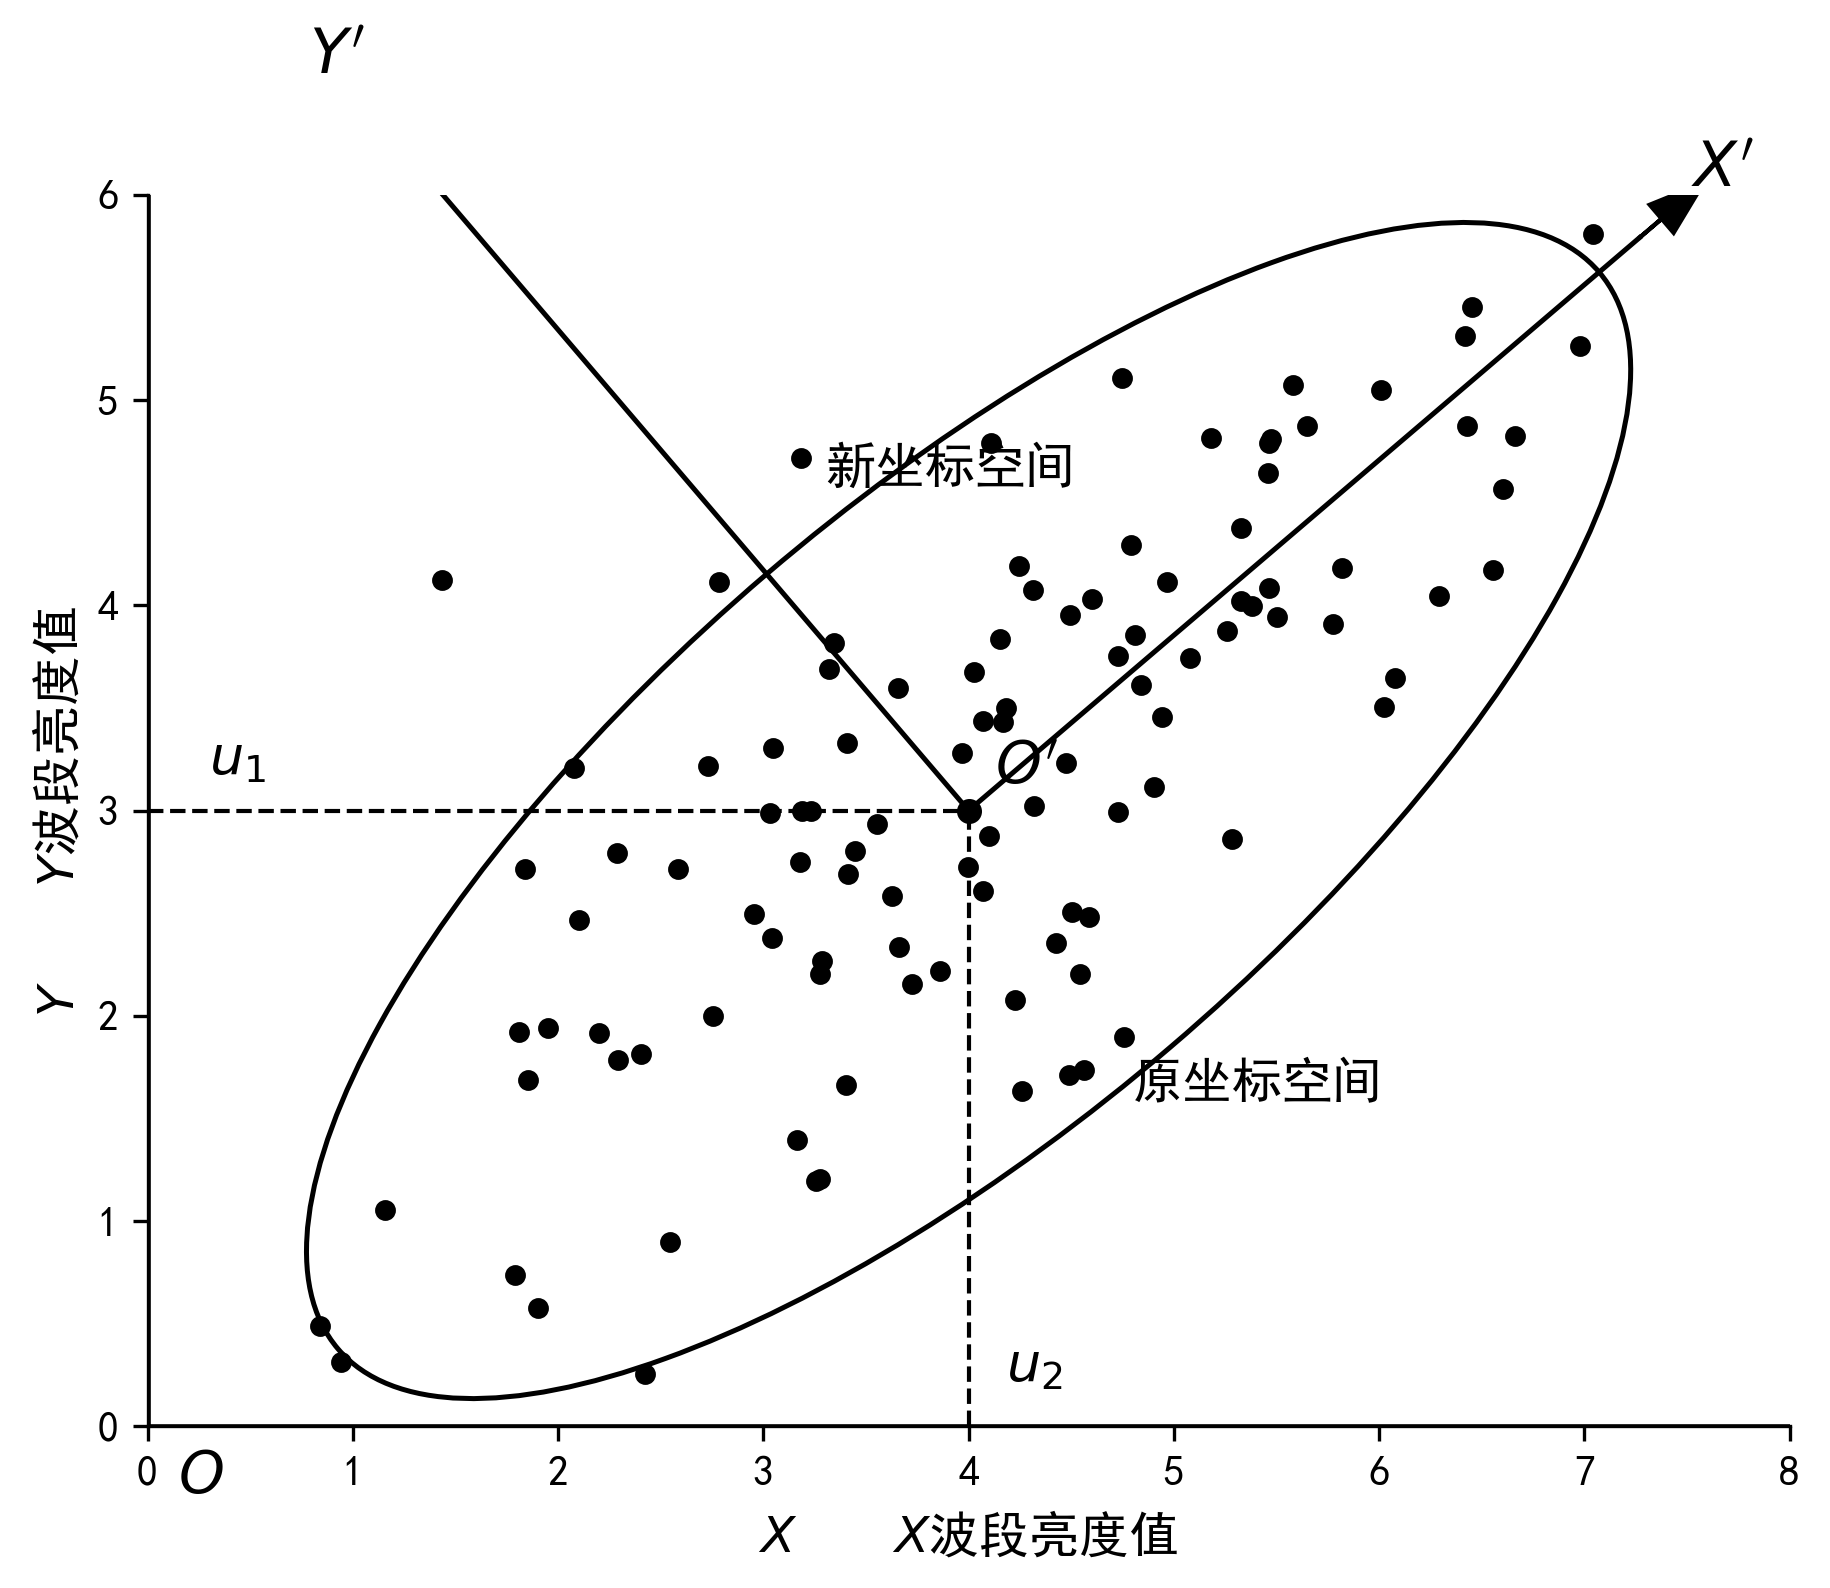

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ===================== 论文绘图全局配置 =====================
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12

# ===================== 1. 生成相关二维样本数据 =====================
np.random.seed(42)
# 样本中心O'坐标 u2=4, u1=3
mu = np.array([4, 3])
# 协方差矩阵，匹配图中倾斜椭圆分布
cov_matrix = [[2.7, 2.1],
              [2.1, 2.4]]
n_points = 110
data = np.random.multivariate_normal(mu, cov_matrix, n_points)
X = data[:, 0]
Y = data[:, 1]

# ===================== 2. PCA求解主成分方向 X' Y' =====================
cov_data = np.cov(data.T)
eig_vals, eig_vecs = np.linalg.eig(cov_data)
# 第一主成分X'（方差最大）、第二主成分Y'
vec_Xp = eig_vecs[:, np.argmax(eig_vals)]
vec_Yp = eig_vecs[:, np.argmin(eig_vals)]
# 椭圆旋转角度
ellipse_angle = np.rad2deg(np.arctan2(vec_Xp[1], vec_Xp[0]))

# ===================== 3. 创建画布 =====================
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.set_xlim(0, 8)
ax.set_ylim(0, 6)
ax.set_aspect("equal")

# 绘制原始坐标轴 X/Y波段亮度
ax.set_xlabel(r"$X$    $X$波段亮度值")
ax.set_ylabel(r"$Y$    $Y$波段亮度值")
ax.axhline(y=0, c="black", lw=1.1)
ax.axvline(x=0, c="black", lw=1.1)
ax.text(0.15, -0.32, r"$O$", fontsize=14)

# 绘制黑色样本散点
ax.scatter(X, Y, c="black", s=16, zorder=4)

# ===================== 4. 绘制样本包围椭圆 =====================
ellipse = Ellipse(
    xy=mu,
    width=2 * np.sqrt(eig_vals[0]) * 2.2,
    height=2 * np.sqrt(eig_vals[1]) * 2.2,
    angle=ellipse_angle,
    fill=False, edgecolor="black", lw=1.2
)
ax.add_patch(ellipse)

# ===================== 5. 中心O' + 均值虚线u1 u2 =====================
ax.scatter(mu[0], mu[1], c="black", s=25, zorder=6)
ax.text(mu[0]+0.13, mu[1]+0.13, r"$O'$", fontsize=14)
# 水平虚线 u1 (Y方向均值)
ax.plot([0, mu[0]], [mu[1], mu[1]], linestyle="--", c="black", lw=1)
ax.text(0.3, mu[1]+0.18, r"$u_1$", fontsize=13)
# 垂直虚线 u2 (X方向均值)
ax.plot([mu[0], mu[0]], [0, mu[1]], linestyle="--", c="black", lw=1)
ax.text(mu[0]+0.18, 0.22, r"$u_2$", fontsize=13)

# ===================== 6. 绘制旋转后主坐标轴 X'、Y' 带箭头 =====================
axis_extend = 4.3
# X' 第一主成分轴
x1_end = mu[0] + vec_Xp[0] * axis_extend
y1_end = mu[1] + vec_Xp[1] * axis_extend
ax.plot([mu[0], x1_end], [mu[1], y1_end], c="black", lw=1.2)
ax.arrow(x1_end, y1_end, 0.14*vec_Xp[0], 0.14*vec_Xp[1], head_width=0.18, fc="black", ec="black")
ax.text(x1_end+0.25, y1_end+0.25, r"$X'$", fontsize=15)

# Y' 第二正交主成分轴
x2_end = mu[0] + vec_Yp[0] * axis_extend
y2_end = mu[1] + vec_Yp[1] * axis_extend
ax.plot([mu[0], x2_end], [mu[1], y2_end], c="black", lw=1.2)
ax.arrow(x2_end, y2_end, 0.14*vec_Yp[0], 0.14*vec_Yp[1], head_width=0.18, fc="black", ec="black")
ax.text(x2_end-0.42, y2_end+0.32, r"$Y'$", fontsize=15)

# ===================== 7. 区域文字标注 =====================
ax.text(4.8, 1.6, "原坐标空间", fontsize=12)
ax.text(3.3, 4.6, "新坐标空间", fontsize=12)

# 隐藏右上多余边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_pca_rotate_diagram.png", bbox_inches="tight")
plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\P'
<>:68: SyntaxWarning: invalid escape sequence '\P'
C:\Users\86138\AppData\Local\Temp\ipykernel_29032\514244934.py:68: SyntaxWarning: invalid escape sequence '\P'
  ax3.set_title('经$\Phi(x)$映射后的高维特征空间（线性可分）')


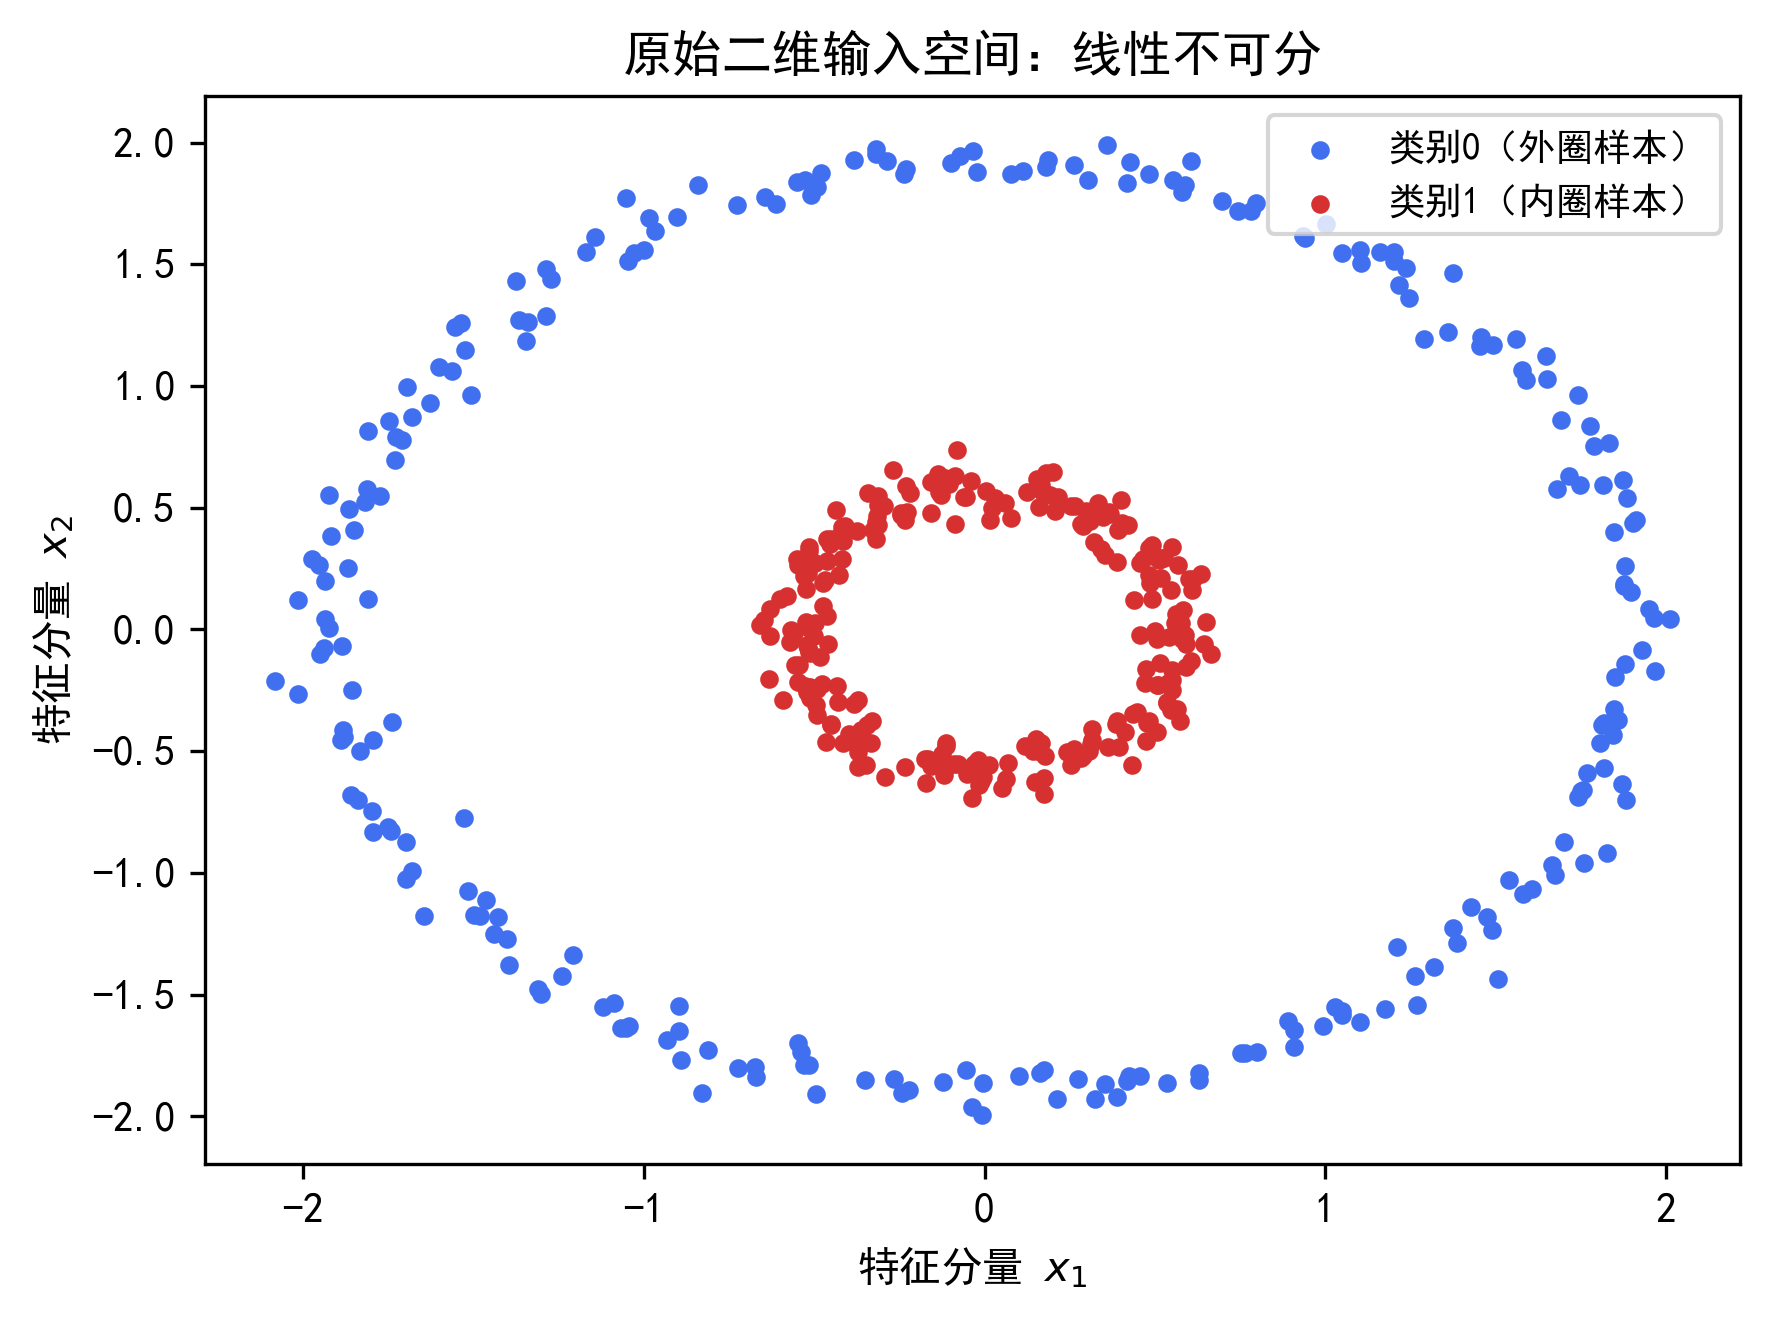

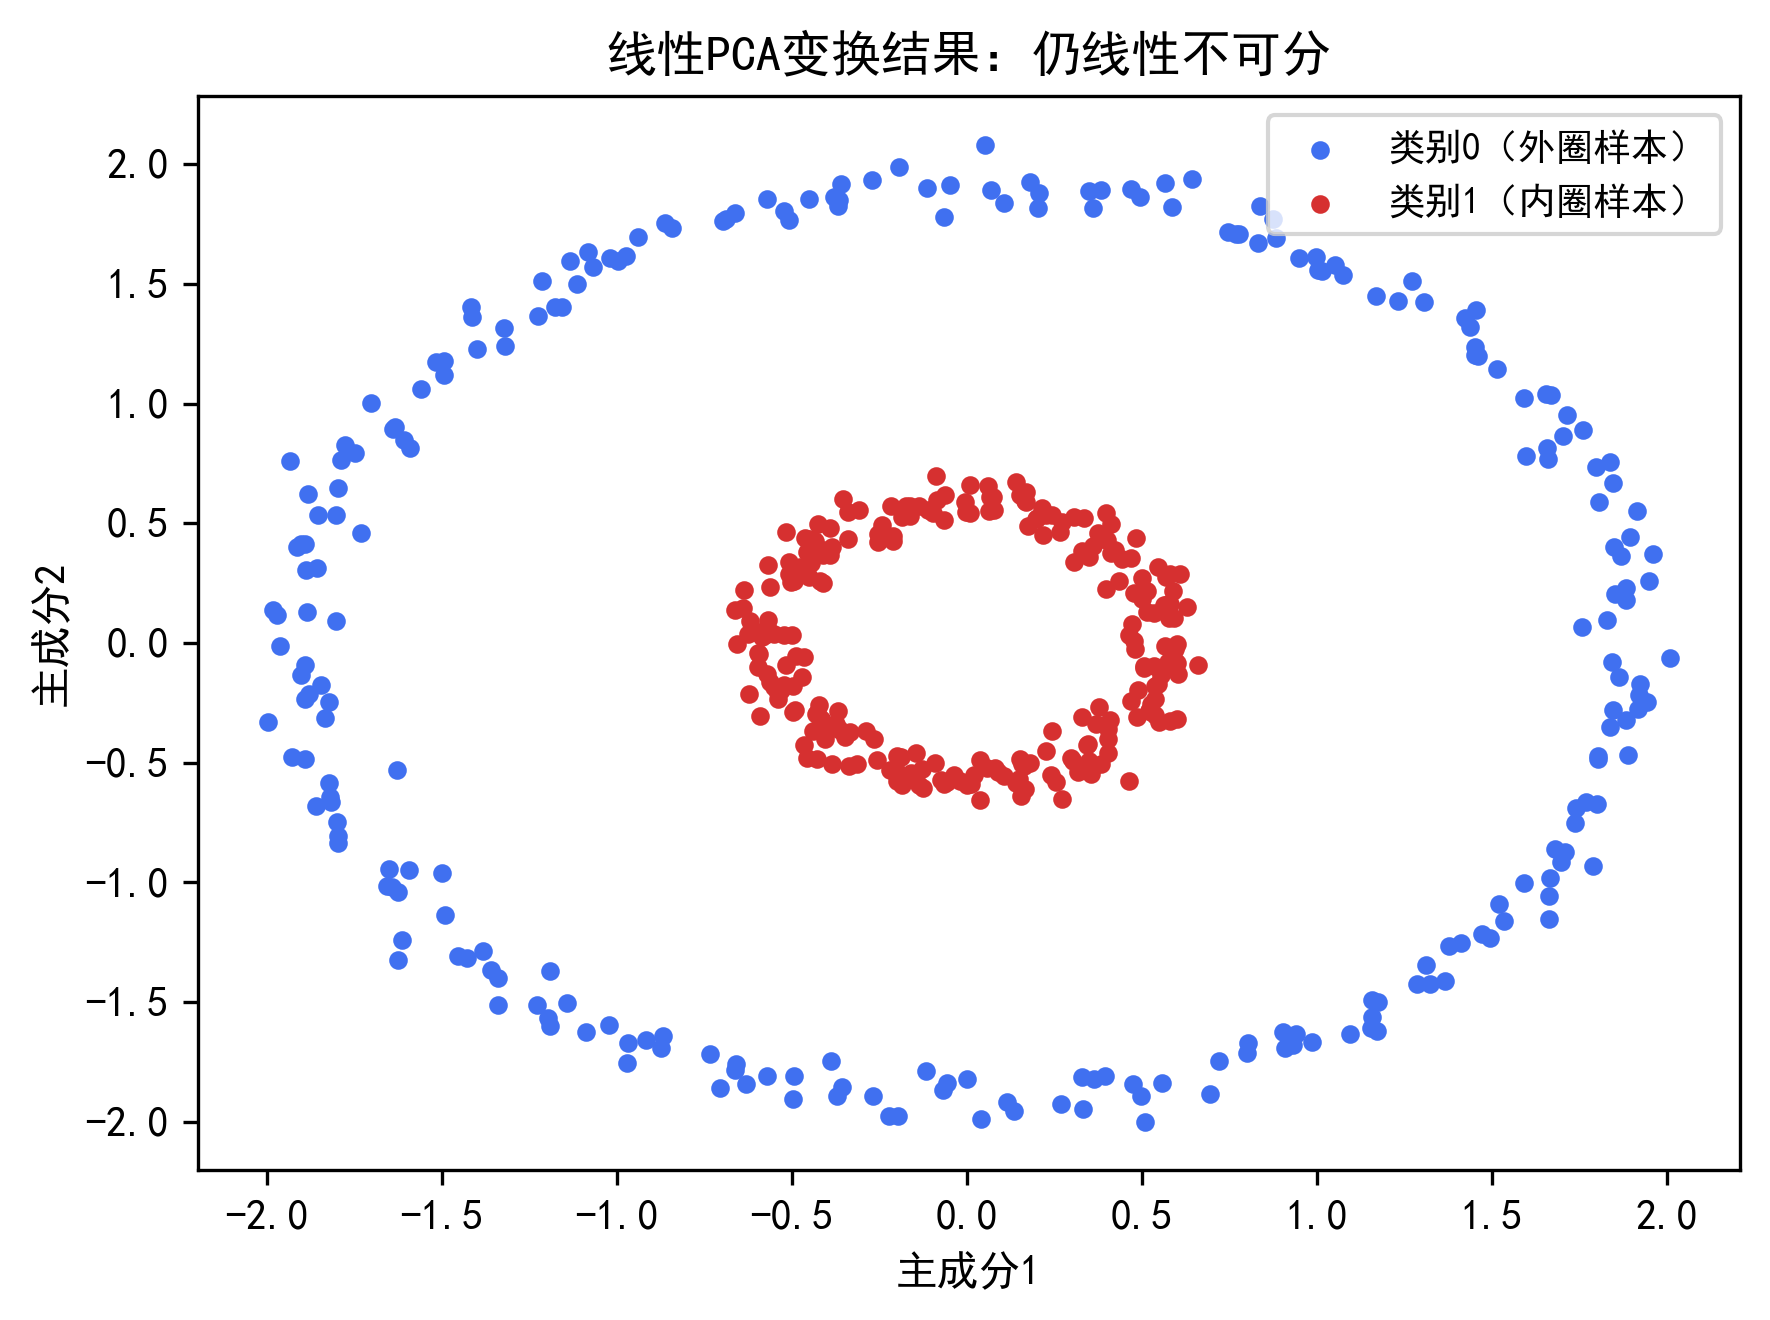

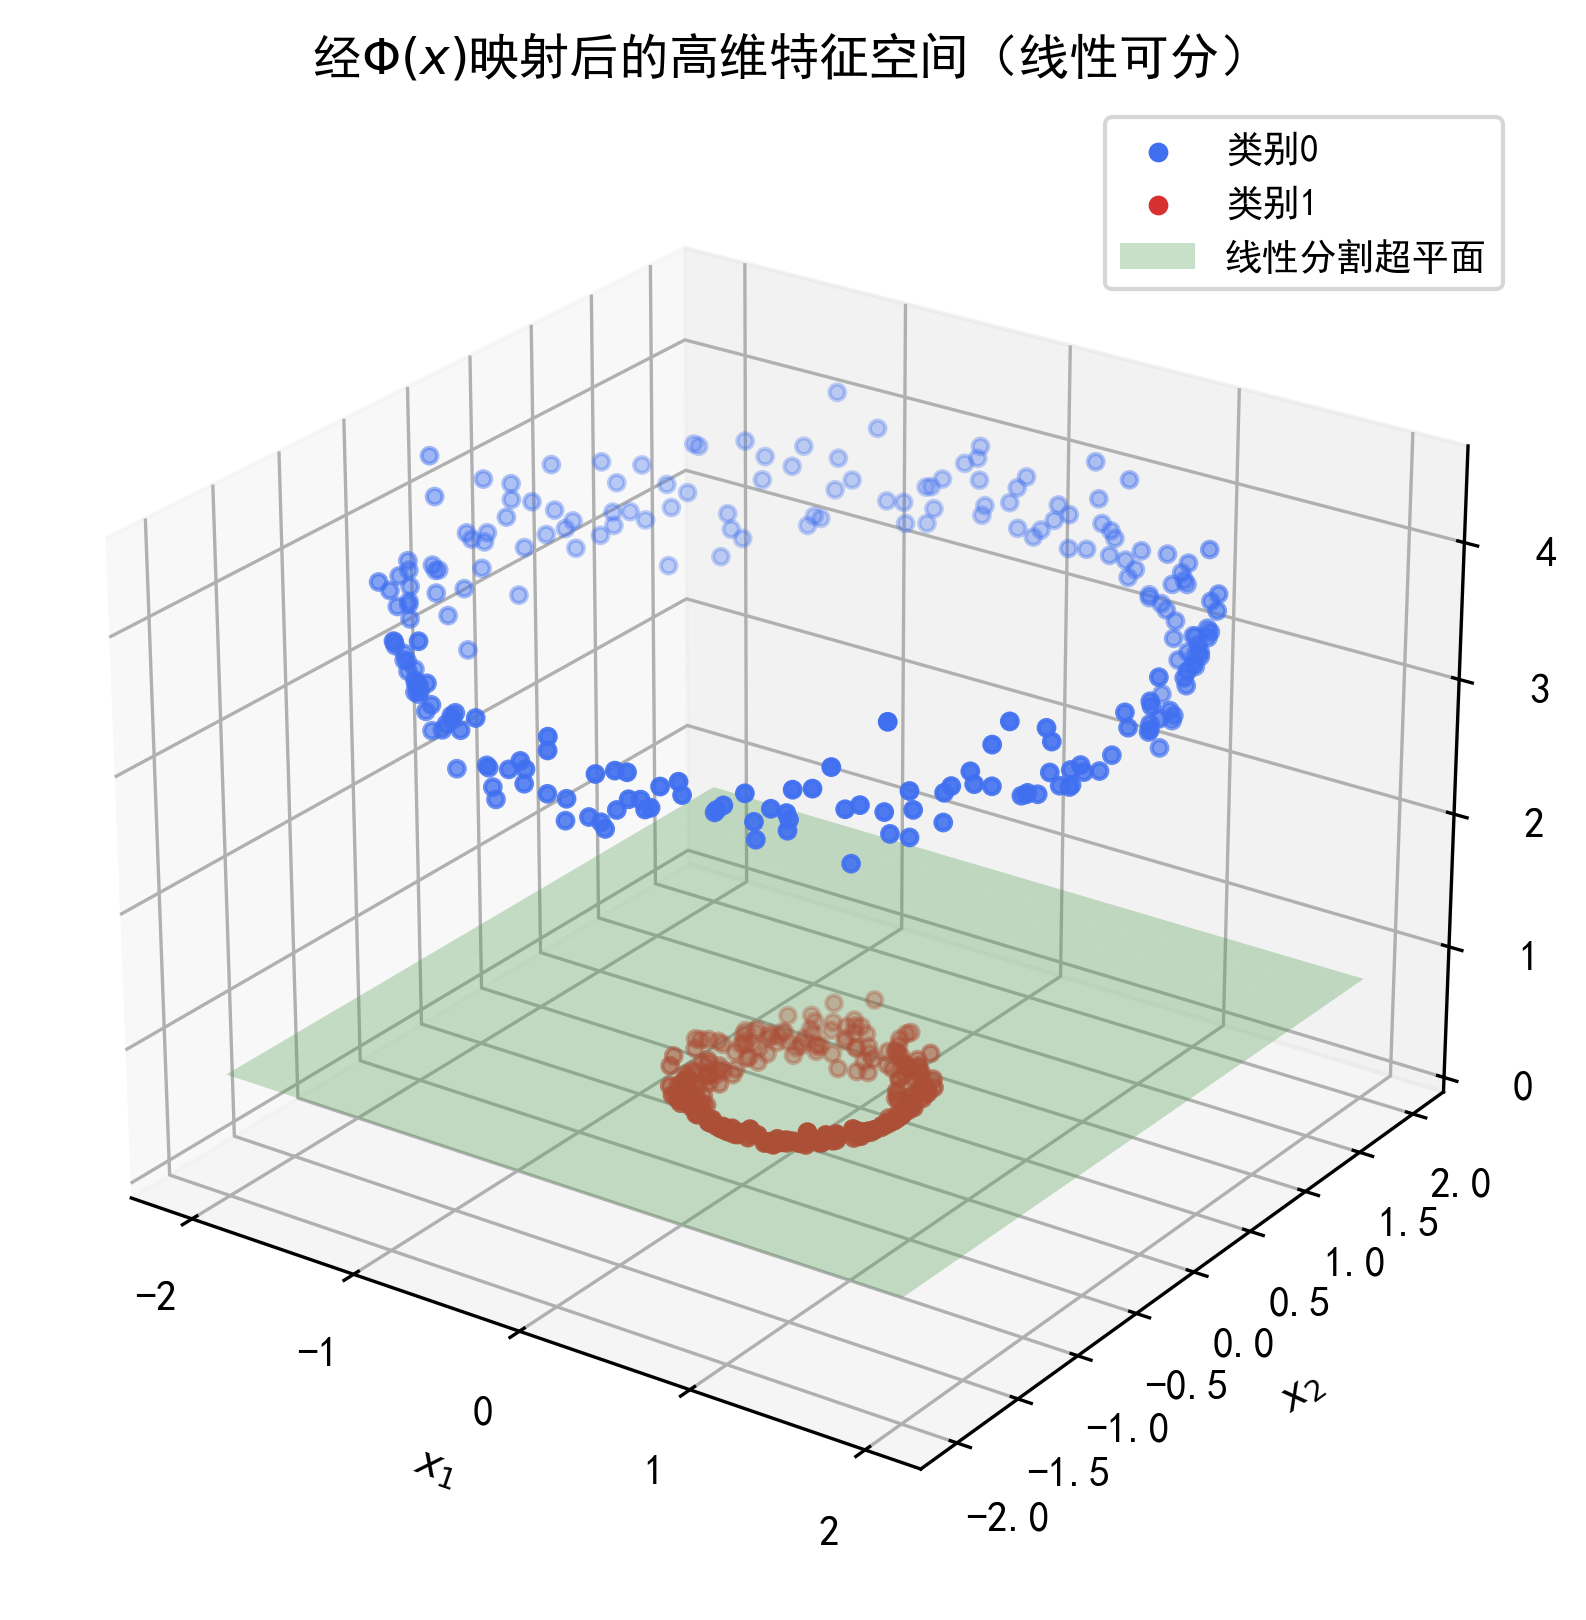

In [69]:
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 论文绘图全局配置（印刷清晰、宋体、无中文乱码）
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# 生成标准化低噪声环形数据集
X, y = make_circles(n_samples=500, noise=0.03, factor=0.3, random_state=2026)
scaler = StandardScaler()
X = scaler.fit_transform(X)
# 线性PCA变换
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# 显式非线性映射 Φ(x1,x2)=(x1, x2, x1²+x2²)
def phi_mapping(raw_x):
    x1 = raw_x[:, [0]]
    x2 = raw_x[:, [1]]
    z = x1**2 + x2**2
    return np.hstack([x1, x2, z])
X_3d = phi_mapping(X)

# ====================== 图1：原始二维空间（单独生成保存） ======================
fig1 = plt.figure(figsize=(6, 4.5))
ax1 = fig1.add_subplot(111)
ax1.scatter(X[y==0,0], X[y==0,1], c='#4070f0', s=12, label='类别0（外圈样本）')
ax1.scatter(X[y==1,0], X[y==1,1], c='#d63030', s=12, label='类别1（内圈样本）')
ax1.set_title('原始二维输入空间：线性不可分')
ax1.set_xlabel('特征分量 $x_1$')
ax1.set_ylabel('特征分量 $x_2$')
ax1.legend()
plt.tight_layout()
plt.savefig("fig1_original_space.png", bbox_inches='tight')
plt.show()

# ====================== 图2：线性PCA变换结果（单独生成保存） ======================
fig2 = plt.figure(figsize=(6, 4.5))
ax2 = fig2.add_subplot(111)
ax2.scatter(X_pca[y==0,0], X_pca[y==0,1], c='#4070f0', s=12, label='类别0（外圈样本）')
ax2.scatter(X_pca[y==1,0], X_pca[y==1,1], c='#d63030', s=12, label='类别1（内圈样本）')
ax2.set_title('线性PCA变换结果：仍线性不可分')
ax2.set_xlabel('主成分1')
ax2.set_ylabel('主成分2')
ax2.legend()
plt.tight_layout()
plt.savefig("fig2_linear_pca.png", bbox_inches='tight')
plt.show()

# ====================== 图3：Φ(x)映射后3维高维特征空间（单独生成保存） ======================
fig3 = plt.figure(figsize=(7, 5.5))
ax3 = fig3.add_subplot(111, projection='3d')
# 绘制样本
ax3.scatter(X_3d[y==0,0], X_3d[y==0,1], X_3d[y==0,2], c='#4070f0', s=14, label='类别0')
ax3.scatter(X_3d[y==1,0], X_3d[y==1,1], X_3d[y==1,2], c='#d63030', s=14, label='类别1')
# 绘制线性分割平面
xx_plane, yy_plane = np.meshgrid(np.linspace(-2, 2, 20), np.linspace(-2, 2, 20))
zz_plane = np.full_like(xx_plane, 0.8)
ax3.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.3, color='#60c860', label='线性分割超平面')
# 坐标轴与标题
ax3.set_xlabel('$x_1$')
ax3.set_ylabel('$x_2$')
ax3.set_zlabel('$z=x_1^2+x_2^2$')
ax3.set_title('经$\Phi(x)$映射后的高维特征空间（线性可分）')
ax3.view_init(elev=25, azim=-55)
ax3.legend()
plt.tight_layout()
plt.savefig("fig3_high_dim_F_space.png", bbox_inches='tight')
plt.show()

去噪后波段：181，有效地物样本：10249


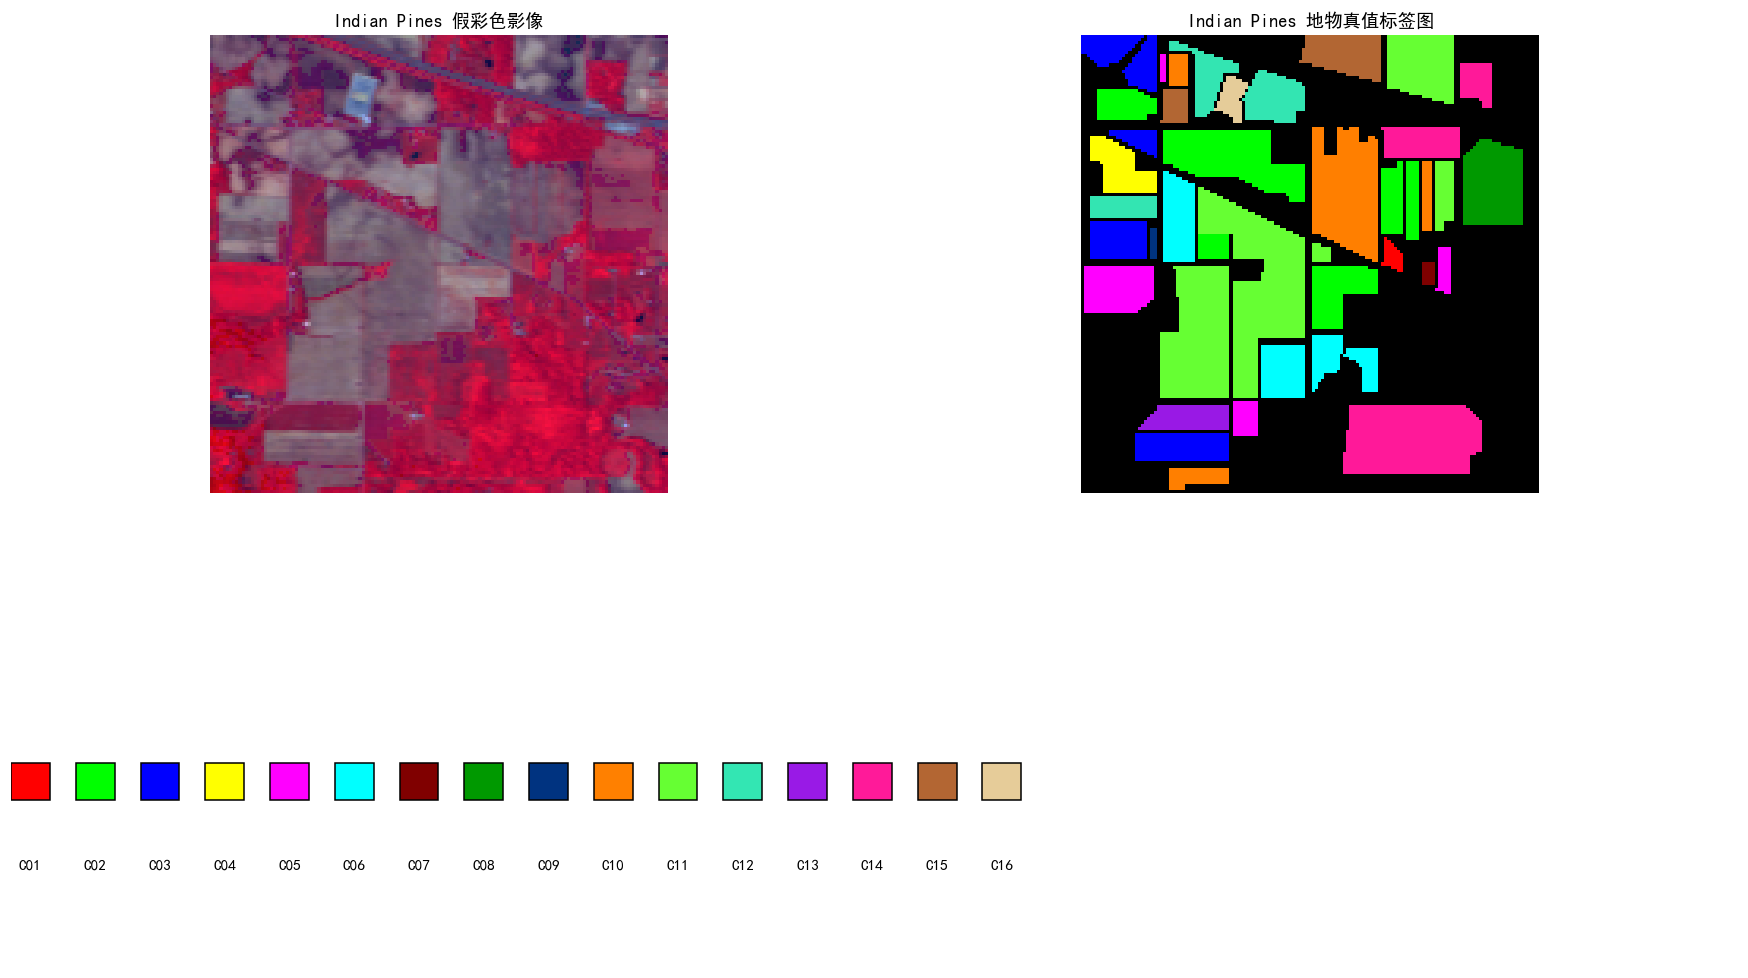

In [68]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from scipy.io import loadmat

# 绘制 假彩色原图 + 真值标签图 + 紧凑正方形图例（文字在方块下方）
def draw_rgb_gt(X_raw, gt_raw):
    h, w, band = X_raw.shape
    # 1. 假彩色合成：选用红外波段 [50, 30, 10] 作为R/G/B
    rgb = np.zeros((h, w, 3))
    rgb[:,:,0] = X_raw[:,:,50]
    rgb[:,:,1] = X_raw[:,:,30]
    rgb[:,:,2] = X_raw[:,:,10]
    # 归一化到0~1显示
    rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))

    # 2. 配色（严格统一：背景+16类地物，图例和真值图共用）
    cmap_colors = [
        [0,0,0],        # 0 背景黑色
        [1.0, 0.0, 0.0],    # C01 1 红
        [0.0, 1.0, 0.0],    # C02 2 亮绿
        [0.0, 0.0, 1.0],    # C03 3 纯蓝
        [1.0, 1.0, 0.0],    # C04 4 黄
        [1.0, 0.0, 1.0],    # C05 5 粉紫
        [0.0, 1.0, 1.0],    # C06 6 青
        [0.5, 0.0, 0.0],    # C07 7 深红棕
        [0.0, 0.6, 0.0],    # C08 8 深绿
        [0.0, 0.2, 0.5],    # C09 9 藏青
        [1.0, 0.5, 0.0],    # C10 10 橙
        [0.4, 1.0, 0.2],    # C11 11 浅黄绿
        [0.2, 0.9, 0.7],    # C12 12 薄荷青
        [0.6, 0.1, 0.9],    # C13 13 紫
        [1.0, 0.1, 0.6],    # C14 14 玫红
        [0.7, 0.4, 0.2],    # C15 15 棕
        [0.9, 0.8, 0.6]     # C16 16 浅米黄
    ]
    custom_cmap = ListedColormap(cmap_colors)
    leg_labels = [f"C{i:02d}" for i in range(1, 17)]

    # 画布：2行布局，上排2张子图，下排整行紧凑图例
    plt.figure(figsize=(16, 9), dpi=110)
    # 左图：假彩色影像
    plt.subplot(2, 2, 1)
    plt.imshow(rgb)
    plt.title("Indian Pines 假彩色影像", fontsize=12)
    plt.axis("off")
    # 右图：真值标签图
    plt.subplot(2, 2, 2)
    plt.imshow(gt_raw, cmap=custom_cmap)
    plt.title("Indian Pines 地物真值标签图", fontsize=12)
    plt.axis("off")

    # ========== 底部图例子图：全部色块放在同一行，文字在方块正下方 ==========
    ax_leg = plt.subplot(2, 1, 2)
    ax_leg.set_xlim(0, 8.0)
    ax_leg.set_ylim(0, 2.2)
    ax_leg.axis("off")
    # 正方形色块尺寸
    square_size = 0.18
    gap = 0.12
    text_y_offset = -0.28  # 文字放在方块下方

    # 循环全部16个，只画一行，不再分两行
    for i in range(16):
        x_pos = i * (square_size + gap)
        # 绘制小正方形色块，带黑边框
        rect = Rectangle((x_pos, 0.8), square_size, square_size,
                         facecolor=cmap_colors[i+1], edgecolor="black", linewidth=1)
        ax_leg.add_patch(rect)
        # 文字在方块正下方，居中对齐
        ax_leg.text(x_pos + square_size/2, 0.8 + text_y_offset, leg_labels[i],
                    fontsize=10, ha="center", va="top")

    plt.tight_layout()
    plt.savefig("Indian_Pines_影像真值对比图.png", bbox_inches='tight')
    plt.show()

def load_indian_pines():
    data_mat = loadmat("./data/Indian_pines_corrected.mat")
    gt_mat = loadmat("./data/Indian_pines_gt.mat")
    data_3d = data_mat["indian_pines_corrected"]  # 原始 (145,145,200) 用于画图
    gt_2d = gt_mat["indian_pines_gt"]            # 原始 (145,145) 用于画图
    h, w, bands = data_3d.shape
    X = data_3d.reshape(-1, bands)
    y = gt_2d.reshape(-1)
    mask = y != 0
    X = X[mask]
    y = y[mask]
    # 剔除水汽噪声波段
    noise_bands = list(range(104, 109)) + list(range(150, 164))
    valid_bands = [i for i in range(bands) if i not in noise_bands]
    X = X[:, valid_bands]
    print(f"去噪后波段：{X.shape[1]}，有效地物样本：{X.shape[0]}")
    return X, y, data_3d, gt_2d

# 运行
X, y, raw_img, raw_gt = load_indian_pines()
draw_rgb_gt(raw_img, raw_gt)

去噪后波段：181，有效地物样本：10249
==== PCA 主成分贡献率 ====
PC1 单贡献率:0.656516 累计:0.656516
PC2 单贡献率:0.208635 累计:0.865152
PC3 单贡献率:0.032620 累计:0.897772
PC4 单贡献率:0.019094 累计:0.916866
PCA达到0.95方差所需分量：9，耗时：0.01s
==== KPCA 主成分贡献率 ====
PC1 单贡献率:0.618446 累计:0.618446
PC2 单贡献率:0.197690 累计:0.816136
PC3 单贡献率:0.037759 累计:0.853895
PC4 单贡献率:0.022805 累计:0.876701
KPCA达到0.95方差所需分量：15，耗时：94.47s
==== LDA降维 ====
LDA输出维度：15，降维耗时：0.16s

==== 三种降维算法分类结果汇总 ====
PCA-MLP   OA:81.27%  Kappa:0.7864  降维耗时:0.01s 分类耗时:11.6s
KPCA-MLP  OA:82.05% Kappa:0.7947 降维耗时:94.47s 分类耗时:16.6s
LDA-MLP   OA:86.60%  Kappa:0.8476  降维耗时:0.16s 分类耗时:10.8s


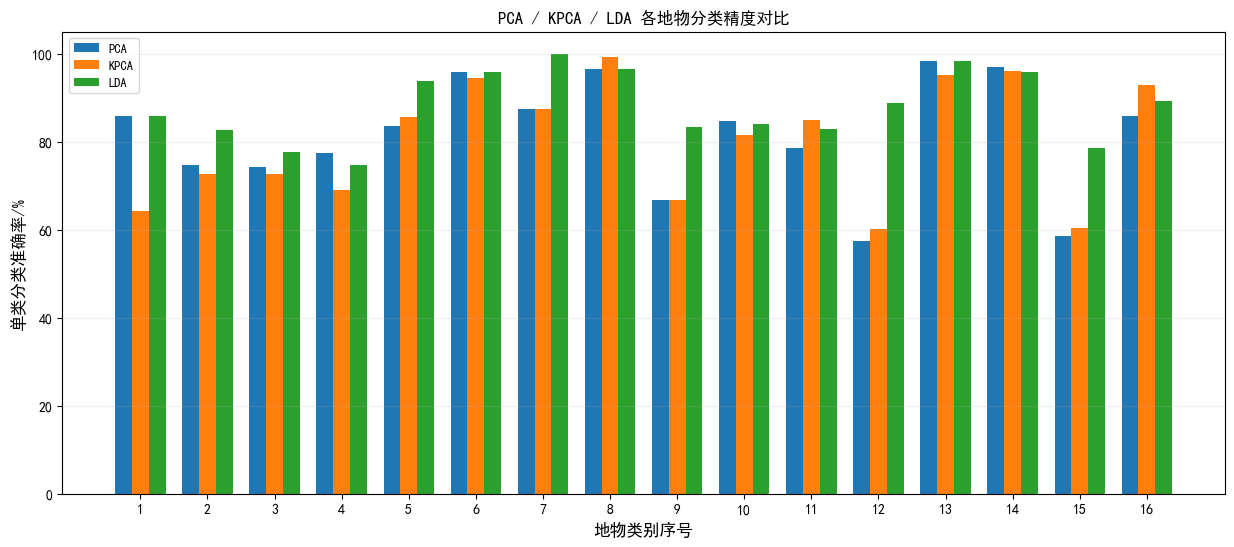

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import time
from numpy.linalg import LinAlgError

# 1. 加载Indian Pines并剔除噪声波段（论文预处理）
def load_indian_pines():
    data_mat = loadmat("./data/Indian_pines_corrected.mat")
    gt_mat = loadmat("./data/Indian_pines_gt.mat")
    data = data_mat["indian_pines_corrected"]
    gt = gt_mat["indian_pines_gt"]
    h, w, bands = data.shape
    X = data.reshape(-1, bands)
    y = gt.reshape(-1)
    mask = y != 0
    X = X[mask]
    y = y[mask]
    # 剔除水汽噪声波段
    noise_bands = list(range(104, 109)) + list(range(150, 164))
    valid_bands = [i for i in range(bands) if i not in noise_bands]
    X = X[:, valid_bands]
    print(f"去噪后波段：{X.shape[1]}，有效地物样本：{X.shape[0]}")
    return X, y

# 2. PCA无监督降维
def pca_dim_reduce(X, threshold=0.95):
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)
    t0 = time.time()
    pca = PCA(n_components=threshold)
    X_pca = pca.fit_transform(X_std)
    t_cost = time.time() - t0
    evr = pca.explained_variance_ratio_
    cum_evr = np.cumsum(evr)
    print("==== PCA 主成分贡献率 ====")
    for i in range(min(4, len(evr))):
        print(f"PC{i+1} 单贡献率:{evr[i]:.6f} 累计:{cum_evr[i]:.6f}")
    print(f"PCA达到0.95方差所需分量：{pca.n_components_}，耗时：{t_cost:.2f}s")
    return X_pca, scaler, t_cost

# 3. KPCA多项式核（论文原版，无scale参数）
def kpca_dim_reduce(X, scaler, threshold=0.95):
    X_std = scaler.transform(X)
    t0 = time.time()
    try:
        kpca = KernelPCA(
            kernel="poly",
            gamma=0.001,
            degree=2,
            coef0=1.0,
            n_components=None,
            tol=1e-4
        )
        X_kpca = kpca.fit_transform(X_std)
        eigen_vals = kpca.eigenvalues_
        total = np.sum(eigen_vals)
        evr = eigen_vals / total
        cum_evr = np.cumsum(evr)
        d = np.argmax(cum_evr >= threshold) + 1
        X_kpca = X_kpca[:, :d]
    except LinAlgError:
        print("KPCA矩阵奇异，降级参数重试")
        kpca = KernelPCA(
            kernel="poly",
            gamma=0.0001,
            degree=1,
            coef0=0.5,
            n_components=None,
            tol=1e-3
        )
        X_kpca = kpca.fit_transform(X_std)
        eigen_vals = kpca.eigenvalues_
        total = np.sum(eigen_vals)
        evr = eigen_vals / total
        cum_evr = np.cumsum(evr)
        d = np.argmax(cum_evr >= threshold) + 1
        X_kpca = X_kpca[:, :d]
    t_cost = time.time() - t0
    print("==== KPCA 主成分贡献率 ====")
    for i in range(min(4, len(evr))):
        print(f"PC{i+1} 单贡献率:{evr[i]:.6f} 累计:{cum_evr[i]:.6f}")
    print(f"KPCA达到0.95方差所需分量：{d}，耗时：{t_cost:.2f}s")
    return X_kpca, t_cost

# 4. 新增LDA监督降维（必须传入标签y）
def lda_dim_reduce(X, y, scaler):
    X_std = scaler.transform(X)
    t0 = time.time()
    # LDA最大维度 = 类别数-1
    lda = LDA()
    X_lda = lda.fit_transform(X_std, y)
    t_cost = time.time() - t0
    print(f"==== LDA降维 ====")
    print(f"LDA输出维度：{X_lda.shape[1]}，降维耗时：{t_cost:.2f}s")
    return X_lda, t_cost

# 5. 分层划分训练测试（保证每类都有样本）
def split_train_test(X, y, train_ratio=0.7):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_ratio, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

# 6. MLP分类评估（和论文保持一致）
def mlp_classify(X_train, X_test, y_train, y_test):
    mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=800, random_state=42)
    t0 = time.time()
    mlp.fit(X_train, y_train)
    pred = mlp.predict(X_test)
    t_cost = time.time() - t0
    oa = accuracy_score(y_test, pred) * 100
    kappa = cohen_kappa_score(y_test, pred)
    return oa, kappa, t_cost, pred, y_test

# 7. 三类算法各地物精度对比图
def plot_category_acc(X_pca, X_kpca, X_lda, y_all):
    Xtr_p, Xte_p, ytr, yte = split_train_test(X_pca, y_all, 0.7)
    Xtr_k, Xte_k, _, _ = split_train_test(X_kpca, y_all, 0.7)
    Xtr_l, Xte_l, _, _ = split_train_test(X_lda, y_all, 0.7)

    mlp_p = MLPClassifier((64,32), max_iter=800, random_state=42)
    mlp_k = MLPClassifier((64,32), max_iter=800, random_state=42)
    mlp_l = MLPClassifier((64,32), max_iter=800, random_state=42)
    mlp_p.fit(Xtr_p, ytr)
    mlp_k.fit(Xtr_k, ytr)
    mlp_l.fit(Xtr_l, ytr)

    pred_p = mlp_p.predict(Xte_p)
    pred_k = mlp_k.predict(Xte_k)
    pred_l = mlp_l.predict(Xte_l)

    labels = np.sort(np.unique(yte))
    acc_pca, acc_kpca, acc_lda = [], [], []
    for c in labels:
        mask = yte == c
        cnt = np.sum(mask)
        if cnt == 0:
            acc_pca.append(0)
            acc_kpca.append(0)
            acc_lda.append(0)
            continue
        a1 = np.sum(pred_p[mask]==c) / cnt * 100
        a2 = np.sum(pred_k[mask]==c) / cnt * 100
        a3 = np.sum(pred_l[mask]==c) / cnt * 100
        acc_pca.append(a1)
        acc_kpca.append(a2)
        acc_lda.append(a3)

    x = np.arange(len(labels))
    w = 0.25
    plt.figure(figsize=(15,6), dpi=100)
    plt.bar(x - w, acc_pca, w, label="PCA")
    plt.bar(x, acc_kpca, w, label="KPCA")
    plt.bar(x + w, acc_lda, w, label="LDA")
    plt.xlabel("地物类别序号")
    plt.ylabel("单类分类准确率/%")
    plt.xticks(x, labels)
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.title("PCA / KPCA / LDA 各地物分类精度对比")
    plt.show()

# ====================== 主程序 ======================
if __name__ == "__main__":
    # 加载数据
    X, y = load_indian_pines()

    # 1.PCA降维 + 统一标准化器
    X_pca, scaler, time_pca = pca_dim_reduce(X, threshold=0.95)
    # 2.KPCA降维（同数据、同标准化）
    X_kpca, time_kpca = kpca_dim_reduce(X, scaler, threshold=0.95)
    # 3.新增LDA监督降维
    X_lda, time_lda = lda_dim_reduce(X, y, scaler)

    # 分层划分训练测试集
    Xtr_p, Xte_p, ytr, yte = split_train_test(X_pca, y, 0.7)
    Xtr_k, Xte_k, _, _ = split_train_test(X_kpca, y, 0.7)
    Xtr_l, Xte_l, _, _ = split_train_test(X_lda, y, 0.7)

    # MLP分类评估
    oa_pca, kappa_pca, t_mlp_p, _, _ = mlp_classify(Xtr_p, Xte_p, ytr, yte)
    oa_kpca, kappa_kpca, t_mlp_k, _, _ = mlp_classify(Xtr_k, Xte_k, ytr, yte)
    oa_lda, kappa_lda, t_mlp_l, _, _ = mlp_classify(Xtr_l, Xte_l, ytr, yte)

    # 输出汇总表格
    print("\n==== 三种降维算法分类结果汇总 ====")
    print(f"PCA-MLP   OA:{oa_pca:.2f}%  Kappa:{kappa_pca:.4f}  降维耗时:{time_pca:.2f}s 分类耗时:{t_mlp_p:.1f}s")
    print(f"KPCA-MLP  OA:{oa_kpca:.2f}% Kappa:{kappa_kpca:.4f} 降维耗时:{time_kpca:.2f}s 分类耗时:{t_mlp_k:.1f}s")
    print(f"LDA-MLP   OA:{oa_lda:.2f}%  Kappa:{kappa_lda:.4f}  降维耗时:{time_lda:.2f}s 分类耗时:{t_mlp_l:.1f}s")

    # 绘制三类算法精度对比柱状图
    plot_category_acc(X_pca, X_kpca, X_lda, y)